# UTS — Klasifikasi Teks Berita dengan Word2Vec Skip-gram dan Naive Bayes

Notebook ini dibuat ulang berdasarkan alur referensi UTS, tetapi menggunakan dataset proyek PPW `data/teks_bersih.csv` dan beberapa parameter/tampilan yang berbeda.


Model deployment disimpan sebagai `model.pkl` untuk digunakan kembali di Streamlit.

## 1. Instalasi Library
Jika belum terpasang pada Python 3.12:
```python
%pip install pandas numpy gensim scikit-learn matplotlib seaborn Sastrawi trafilatura requests beautifulsoup4
```

### Fungsi Masing-Masing Library

| Library | Fungsi Utama |
|---|---|
| `pandas` | Manipulasi data tabular (DataFrame): baca CSV, filter baris/kolom, groupby |
| `numpy` | Komputasi numerik: operasi vektor, matriks, dan array multidimensi |
| `gensim` | Pelatihan **Word2Vec** (Skip-gram / CBOW) berbasis neural network |
| `scikit-learn` | Pembagian data train/test, Gaussian Naive Bayes, metrik evaluasi, PCA |
| `matplotlib` / `seaborn` | Visualisasi: histogram, heatmap confusion matrix, scatter plot PCA |
| `Sastrawi` | Stopword removal dan stemming khusus **Bahasa Indonesia** (±750 stopword) |
| `trafilatura` | Ekstraksi teks artikel bersih dari HTML menggunakan algoritma ML |
| `requests` / `beautifulsoup4` | Fallback crawling manual: fetch HTML dan parsing tag `<p>` |

> **Catatan:** Jalankan `%pip install ...` hanya jika library belum terpasang. Cell kode (#2) sudah di-comment untuk keamanan.


In [ ]:
# Jalankan hanya jika diperlukan
# %pip install pandas numpy gensim scikit-learn matplotlib seaborn Sastrawi trafilatura requests beautifulsoup4

## 2. Import Library

Seluruh modul yang dibutuhkan diimpor di sini sebelum eksekusi apapun.

```python
import re, time, pickle
from collections import Counter
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
warnings.filterwarnings("ignore")
np.random.seed(42)
```

**Mengapa `np.random.seed(42)`?**  
Operasi stokastik (acak) seperti inisialisasi bobot Word2Vec, pembagian data, dan PCA menggunakan bilangan pseudo-random. Dengan menetapkan seed yang sama (42 adalah konvensi komunitas), setiap kali notebook dijalankan akan menghasilkan output yang **identik** — ini penting untuk *reproducibility* dalam penelitian.


In [1]:
import re
import time
import pickle
from collections import Counter
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Library berhasil dimuat.")

Library berhasil dimuat.


## 3. Konfigurasi Eksperimen
Parameter sengaja dibuat tidak identik dengan referensi: `window=4` dan `epochs=40`.

Semua *hyperparameter* eksperimen dipusatkan di satu tempat agar mudah diubah dan didokumentasikan. Dengan pola ini, mengubah satu nilai di bagian atas langsung berdampak ke seluruh pipeline tanpa perlu mencari-cari di tengah kode.

| Parameter | Nilai | Penjelasan |
|---|---|---|
| `VECTOR_SIZE` | 100 | Dimensi ruang vektor embedding setiap kata |
| `WINDOW_SIZE` | 4 | Ukuran jendela konteks kiri-kanan untuk Skip-gram |
| `MIN_COUNT` | 2 | Frekuensi minimum agar kata masuk vocabulary |
| `EPOCHS` | 40 | Jumlah iterasi pelatihan Word2Vec |
| `TEST_SIZE` | 0.20 | Proporsi data uji (20% dari total dataset) |
| `RANDOM_STATE` | 42 | Seed untuk reproducibility |

---

### `VECTOR_SIZE = 100` — Dimensi Embedding

Setiap kata direpresentasikan sebagai **vektor berdimensi 100** di dalam ruang semantik kontinu ($\mathbb{R}^{100}$). Setiap dimensi menangkap aspek semantik tertentu yang dipelajari model secara otomatis dari data.

- **Terlalu kecil** (mis. 10): Tidak cukup kapasitas untuk menyimpan relasi semantik yang kompleks
- **Terlalu besar** (mis. 300+): Risiko *overfitting* pada dataset kecil; komputasi lebih berat
- **100 dimensi**: Pilihan seimbang dan umum untuk dataset skala medium (ribuan dokumen)

---

### `WINDOW_SIZE = 4` — Ukuran Jendela Konteks

Window size menentukan seberapa jauh kata di sekitar kata target dianggap sebagai **konteks**. Dengan `window=4`, untuk setiap kata target $w_t$:

$$\text{Konteks}(w_t) = \{w_{t-4},\ w_{t-3},\ w_{t-2},\ w_{t-1},\ w_{t+1},\ w_{t+2},\ w_{t+3},\ w_{t+4}\}$$

**Contoh** pada kalimat `"harga saham bank mandiri naik signifikan"`:  
Untuk kata target **"bank"** (indeks 2) dengan `window=4`:

| Posisi | Kata | Jarak dari Target |
|:---:|:---|:---:|
| 0 | harga | -2 |
| 1 | saham | -1 |
| **2** | **bank** | **0 (target)** |
| 3 | mandiri | +1 |
| 4 | naik | +2 |
| 5 | signifikan | +3 |

- **Window kecil (1–2)**: Lebih menangkap relasi **sintaksis** (kata kerja ↔ objek)
- **Window besar (5–10)**: Lebih menangkap relasi **semantik/topik** yang luas
- **Window = 4**: Kompromi antara sintaksis dan semantik — cocok untuk klasifikasi teks

---

### `MIN_COUNT = 2` — Frekuensi Minimum Vocabulary

Kata yang muncul **kurang dari 2 kali** dalam seluruh corpus diabaikan dan tidak masuk vocabulary. Manfaatnya:
- Membuang *hapax legomena* (kata yang hanya muncul sekali) yang biasanya noise / typo
- Mengurangi ukuran vocabulary → pelatihan lebih efisien
- Menghindari representasi kata yang tidak akurat karena data tidak cukup

---

### `EPOCHS = 40` — Jumlah Iterasi Pelatihan

Model Word2Vec melewati seluruh corpus sebanyak **40 kali**. Setiap epoch, bobot jaringan diperbarui menggunakan *Stochastic Gradient Descent*:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

Di mana $\theta$ = parameter model, $\eta$ = learning rate, $\mathcal{L}$ = fungsi loss.

- **Default Gensim**: 5 epoch (cepat, tetapi representasi kurang matang)
- **40 epoch**: Lebih matang, representasi vektor lebih kaya secara semantik
- Terlalu banyak epoch bisa boros komputasi tanpa peningkatan signifikan

---

### `TEST_SIZE = 0.20` — Rasio Data Uji

Dataset dibagi dengan rasio **80% latih : 20% uji**:

$$\text{Train} = 80\%\times N, \quad \text{Test} = 20\%\times N$$

Rasio 80:20 adalah standar industri yang memberikan cukup data untuk melatih model sekaligus cukup sampel untuk evaluasi yang representatif.


In [2]:
VECTOR_SIZE=100
WINDOW_SIZE=4
MIN_COUNT=2
EPOCHS=40
TEST_SIZE=0.20
RANDOM_STATE=42
print("Parameter siap:", VECTOR_SIZE, WINDOW_SIZE, MIN_COUNT, EPOCHS)

Parameter siap: 100 4 2 40


## 4. Memuat Data `data/teks_bersih.csv`

Dataset yang digunakan adalah file CSV hasil preprocessing proyek PPW. File ini harus memiliki tiga kolom wajib:

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `id` | string/int | Identifikasi unik setiap artikel berita |
| `teks_bersih` | string | Teks berita yang sudah dibersihkan: lowercase, tanpa tanda baca berlebihan, hasil preprocessing sebelumnya |
| `label` | string | Kategori berita: `"sport"` atau `"finance"` |

**Validasi kolom** dilakukan di awal untuk menerapkan prinsip **fail-fast**: jika ada kolom yang kurang, program langsung berhenti dengan pesan error yang jelas, daripada gagal dengan pesan membingungkan di tahap selanjutnya.

**Langkah pembersihan awal:**
1. Seleksi hanya tiga kolom yang dibutuhkan (`id`, `teks_bersih`, `label`)
2. Hapus baris dengan nilai kosong (`dropna()`)
3. Pastikan `teks_bersih` bertipe string
4. Normalisasi label: lowercase + strip spasi (menghindari `"Sport"` ≠ `"sport"`)


In [3]:
df=pd.read_csv("data/teks_bersih.csv")
required={"id","teks_bersih","label"}
if not required.issubset(df.columns):
    raise ValueError(f"Kolom wajib: {required}; ditemukan: {df.columns.tolist()}")
df=df[["id","teks_bersih","label"]].dropna().copy()
df["teks_bersih"]=df["teks_bersih"].astype(str)
df["label"]=df["label"].astype(str).str.lower().str.strip()
print("Ukuran dataset:",df.shape)
print("\nDistribusi label:")
print(df["label"].value_counts())
display(df.head())

Ukuran dataset: (200, 3)

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


,id,teks_bersih,label
0,1,jakarta atlet bela indonesia asi games aichi n...,sport
1,2,fia world endurance championship pasuk paruh m...,sport
2,3,campus league badminton regional semarang univ...,sport
3,4,kontingen indonesia tatap asi games jepang pre...,sport
4,5,jelang asi games timnas basket x putra terbang...,sport


In [4]:
print("Nilai kosong:")
print(df.isnull().sum())
print("\nDuplikat teks:",df.duplicated("teks_bersih").sum())
df["jumlah_kata"]=df["teks_bersih"].str.split().str.len()
print("\nStatistik jumlah kata:")
display(df["jumlah_kata"].describe())

Nilai kosong:
id             0
teks_bersih    0
label          0
dtype: int64

Duplikat teks: 1

Statistik jumlah kata:


count    200.000000
mean     179.690000
std       86.504677
min       27.000000
25%      126.000000
50%      165.000000
75%      220.250000
max      624.000000
Name: jumlah_kata, dtype: float64

## 5. Tokenisasi dan Filtering Stopword

### Apa itu Tokenisasi?

**Tokenisasi** adalah proses memecah teks menjadi unit-unit terkecil yang bermakna (token/kata). Dalam notebook ini digunakan tokenisasi sederhana berbasis spasi:

```
"harga saham bank naik" → ["harga", "saham", "bank", "naik"]
```

### Stopword Removal dengan Sastrawi

**Stopword** adalah kata-kata umum yang tidak mengandung makna diskriminatif — tidak membantu membedakan kategori *sport* vs *finance*:

> Contoh stopword Indonesia: *yang, dan, di, ini, itu, adalah, dari, ke, pada, untuk, dengan, telah, akan, sudah, ...*

Sastrawi (`PySastrawi`) menyediakan daftar stopword Bahasa Indonesia yang komprehensif (±750 kata), dikurasi khusus untuk teks berbahasa Indonesia.

**Kondisi filter token (dipertahankan jika):**
1. `w not in stopword_set` → bukan kata umum/stopword
2. `len(w) > 1` → panjang minimal 2 karakter (menghindari karakter tunggal sisa noise)

**Contoh transformasi:**
```
Sebelum filter: ["hasil", "pertandingan", "di", "stadion", "ini", "sangat", "bagus"]
                                           ↑                  ↑     ↑
                                        stopword           stopword stopword
Sesudah filter: ["hasil", "pertandingan", "stadion", "bagus"]
```

Hasil tokenisasi tersimpan di dua kolom:
- `tokens` → seluruh token (termasuk stopword) — untuk referensi
- `tokens_model` → token setelah filter stopword — **digunakan untuk pelatihan**


In [5]:
df["tokens"]=df["teks_bersih"].apply(str.split)
factory=StopWordRemoverFactory()
stopword_set=set(factory.get_stop_words())
def filter_stopword(tokens):
    return [w for w in tokens if w not in stopword_set and len(w)>1]
df["tokens_model"]=df["tokens"].apply(filter_stopword)
print("Jumlah stopword Sastrawi:",len(stopword_set))
print("Contoh token:",df["tokens_model"].iloc[0][:20])

Jumlah stopword Sastrawi: 123
Contoh token: ['jakarta', 'atlet', 'bela', 'indonesia', 'asi', 'games', 'aichi', 'nagoya', 'noc', 'tim', 'indonesia', 'day', 'bakar', 'semangat', 'kontingen', 'tanding', 'foto', 'sport', 'obor', 'nyala']


## 6. Pembagian Data Train/Test 80:20

Dataset dibagi menjadi dua subset yang tidak tumpang tindih:
- **Data Train (80%)**: Digunakan untuk melatih Word2Vec dan Naive Bayes
- **Data Test (20%)**: Hanya digunakan untuk evaluasi performa — **tidak boleh "dilihat" model selama training**

### Stratified Split

Parameter `stratify=df["label"]` memastikan proporsi kelas **sport** dan **finance** tetap representatif di kedua subset. Ini krusial untuk dataset yang tidak seimbang (imbalanced).

**Tanpa stratify** — bisa terjadi ketidakseimbangan:
```
Dataset asli:  60% sport, 40% finance
Train:  70% sport, 30% finance   ← terlalu banyak sport
Test:   30% sport, 70% finance   ← terlalu banyak finance  ← tidak representatif!
```

**Dengan stratify** — proporsi dijaga:
```
Dataset asli:  60% sport, 40% finance
Train:  60% sport, 40% finance ✓
Test:   60% sport, 40% finance ✓  ← representatif!
```

**Distribusi split** divisualisasikan dengan crosstab untuk verifikasi keseimbangan.


In [6]:
train_idx,test_idx=train_test_split(df.index,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=df["label"])
df["split"]="Train"
df.loc[test_idx,"split"]="Test"
print("Distribusi split:")
display(pd.crosstab(df["split"],df["label"],margins=True,margins_name="Total"))
corpus_train=df.loc[train_idx,"tokens_model"].tolist()
corpus_test=df.loc[test_idx,"tokens_model"].tolist()
y_train=df.loc[train_idx,"label"].values
y_test=df.loc[test_idx,"label"].values
print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

Distribusi split:


label,finance,sport,Total
split,,,
Test,20,20,40
Train,80,80,160
Total,100,100,200


Train: 160 | Test: 40


## 7. Pemeriksaan Pasangan Target–Context Skip-gram
Contoh ini menampilkan pasangan kata target dan konteks secara eksplisit. Ukuran window adalah 4.

### Konsep Arsitektur Skip-gram

**Skip-gram** adalah arsitektur Word2Vec di mana **kata target memprediksi kata konteksnya** — kebalikan dari CBOW (*Continuous Bag of Words*) yang memprediksi target dari konteks.

```
     CBOW:    [konteks] → [target]     (konteks memprediksi target)
  Skip-gram:  [target]  → [konteks]   (target memprediksi konteks) ← digunakan di sini
```

**Fungsi Objektif Skip-gram** — memaksimalkan log-probabilitas kata konteks diberikan kata target:

$$\mathcal{L} = \frac{1}{T} \sum_{t=1}^{T} \sum_{\substack{-c \leq j \leq c \\ j \neq 0}} \log P(w_{t+j} \mid w_t)$$

Di mana:
- $T$ = total panjang corpus (jumlah token)
- $c$ = ukuran window (`WINDOW_SIZE = 4`)
- $w_t$ = kata target pada posisi $t$
- $w_{t+j}$ = kata konteks pada jarak $j$ dari target

**Probabilitas konteks** dihitung dengan fungsi softmax:

$$P(w_O \mid w_I) = \frac{\exp(\mathbf{v}_{w_O}^\top \mathbf{v}_{w_I})}{\sum_{w=1}^{W} \exp(\mathbf{v}_w^\top \mathbf{v}_{w_I})}$$

Di mana:
- $\mathbf{v}_{w_I} \in \mathbb{R}^{100}$ = vektor input untuk kata target
- $\mathbf{v}_{w_O} \in \mathbb{R}^{100}$ = vektor output untuk kata konteks
- $W$ = ukuran vocabulary

### Pasangan (Target, Konteks) yang Dihasilkan

Untuk kalimat `["harga", "saham", "bank", "naik"]` dengan `window=2`:

| Target | Idx | Context | Idx | Jarak |
|--------|:---:|---------|:---:|:-----:|
| harga  | 0   | saham   | 1   | +1 |
| harga  | 0   | bank    | 2   | +2 |
| saham  | 1   | harga   | 0   | -1 |
| saham  | 1   | bank    | 2   | +1 |
| saham  | 1   | naik    | 3   | +2 |
| bank   | 2   | harga   | 0   | -2 |
| bank   | 2   | saham   | 1   | -1 |
| bank   | 2   | naik    | 3   | +1 |
| naik   | 3   | saham   | 1   | -2 |
| naik   | 3   | bank    | 2   | -1 |

Total pasangan ≈ $N \times 2c$ per kalimat (di mana $N$ = jumlah token, $c$ = window size).


In [7]:
def buat_pasangan_skipgram(tokens,window_size=4):
    rows=[]
    for ti,target in enumerate(tokens):
        start=max(0,ti-window_size); end=min(len(tokens),ti+window_size+1)
        for ci in range(start,end):
            if ci!=ti:
                rows.append({"Target_Word":target,"Target_Idx":ti,"Context_Word":tokens[ci],"Context_Idx":ci,"Jarak":ci-ti})
    return rows
rows=[]
for kalimat_ke,tokens in enumerate(corpus_train,1):
    for r in buat_pasangan_skipgram(tokens,WINDOW_SIZE):
        r["Kalimat_Ke"]=kalimat_ke; rows.append(r)
df_pairs=pd.DataFrame(rows)
print("Jumlah pasangan:",len(df_pairs))
display(df_pairs.head(12))

Jumlah pasangan: 223032


,Target_Word,Target_Idx,Context_Word,Context_Idx,Jarak,Kalimat_Ke
0,indeks,0,harga,1,1,1
1,indeks,0,saham,2,2,1
2,indeks,0,gabung,3,3,1
3,indeks,0,ihsg,4,4,1
4,harga,1,indeks,0,-1,1
5,harga,1,saham,2,1,1
6,harga,1,gabung,3,2,1
7,harga,1,ihsg,4,3,1
8,harga,1,gairah,5,4,1
9,saham,2,indeks,0,-2,1


In [8]:
target_word="belajar"
if target_word not in set(df_pairs["Target_Word"]):
    target_word=Counter(df_pairs["Target_Word"]).most_common(1)[0][0]
df_target=df_pairs[df_pairs["Target_Word"]==target_word].copy()
print(f"🔎 Pemeriksaan khusus kata target: '{target_word}'")
display(df_target[["Kalimat_Ke","Target_Word","Target_Idx","Context_Word","Context_Idx","Jarak"]].head(30))
df_summary_contexts=df_pairs.groupby("Target_Word")["Context_Word"].apply(list).reset_index()
df_summary_contexts.columns=["Kata Target",f"Daftar Kata Konteks (Window={WINDOW_SIZE})"]
print("Ringkasan target dan konteks:")
display(df_summary_contexts.head(20))

🔎 Pemeriksaan khusus kata target: 'indonesia'


,Kalimat_Ke,Target_Word,Target_Idx,Context_Word,Context_Idx,Jarak
1146,2,indonesia,73,dorong,69,-4
1147,2,indonesia,73,kembang,70,-3
1148,2,indonesia,73,olahraga,71,-2
1149,2,indonesia,73,padel,72,-1
1150,2,indonesia,73,hype,74,1
1151,2,indonesia,73,cipta,75,2
1152,2,indonesia,73,gaya,76,3
1153,2,indonesia,73,hidup,77,4
1738,2,indonesia,147,koper,143,-4
1739,2,indonesia,147,tarik,144,-3


Ringkasan target dan konteks:


,Kata Target,Daftar Kata Konteks (Window=4)
0,aan,"[muhammad, castallani, ceo, shiratha, yugiasto..."
1,aau,"[september, akademi, angkat, udara, yogyakarta..."
2,abdi,"[arwana, jaya, muhammad, bima, negara, hasil, ..."
3,abdul,"[jamin, direktur, utama, jamkrindo, bari, kerj..."
4,aberdeen,"[luton, bandara, birmingham, bandara, bandara,..."
5,abraham,"[asi, games, derrick, michael, grahita, ali, b..."
6,absen,"[kali, tim, menang, kelas, porsche, penske, pr..."
7,abt,"[tempo, bayar, uang, anggar, dana, bank, sedia..."
8,abu,"[tutup, akibat, dampak, sebar, vulkanik, gunun..."
9,abullah,"[nugroho, muhamad, khalil, munawar, nomor, gan..."


## 8. Pelatihan Word2Vec Skip-gram

Model Word2Vec dilatih **hanya pada data train** untuk menghindari *data leakage* (kebocoran informasi dari data test).

```python
model_sg = Word2Vec(
    sentences=corpus_train,   # list of lists (kalimat → token)
    vector_size=VECTOR_SIZE,  # 100 → dimensi vektor kata
    window=WINDOW_SIZE,       # 4 → ukuran jendela konteks
    min_count=MIN_COUNT,      # 2 → abaikan kata dengan frekuensi < 2
    sg=1,                     # 1=Skip-gram, 0=CBOW
    workers=1,                # 1 thread → hasil deterministik
    epochs=EPOCHS,            # 40 iterasi
    seed=RANDOM_STATE         # 42 → reproducibility
)
```

**Mengapa `workers=1`?**  
Dengan banyak thread, urutan update bobot bisa berbeda-beda (*race condition*) walaupun seed sama, sehingga model sedikit berbeda di setiap run. `workers=1` menjamin hasil yang **identik** di setiap eksekusi.

---

### Mekanisme Negative Sampling

Gensim secara default menggunakan **Negative Sampling** (bukan full softmax) untuk efisiensi komputasi. Full softmax membutuhkan $O(|V|)$ operasi per update — sangat lambat untuk vocabulary besar. Negative Sampling hanya membedakan pasangan positif (nyata) dari $k$ pasangan negatif (acak):

$$\mathcal{L}_{NS} = \log \sigma(\mathbf{v}_{w_O}^\top \mathbf{v}_{w_I}) + \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)} \left[\log \sigma(-\mathbf{v}_{w_i}^\top \mathbf{v}_{w_I})\right]$$

Di mana:
- $\sigma(x) = \dfrac{1}{1 + e^{-x}}$ = fungsi sigmoid
- $P_n(w) \propto f(w)^{3/4}$ = distribusi noise (frekuensi kata dipangkat 3/4)
- $k$ = jumlah sampel negatif per pasangan positif (default: 5)

Model belajar untuk memberikan nilai tinggi pada pasangan nyata dan nilai rendah pada pasangan negatif acak.


In [9]:
start=time.time()
model_sg=Word2Vec(sentences=corpus_train,vector_size=VECTOR_SIZE,window=WINDOW_SIZE,min_count=MIN_COUNT,sg=1,workers=1,epochs=EPOCHS,seed=RANDOM_STATE)
w2v_time=time.time()-start
print("Waktu:",f"{w2v_time:.2f} detik")
print("Vocabulary:",len(model_sg.wv))
print("Dimensi:",model_sg.wv.vector_size)

Waktu: 14.42 detik
Vocabulary: 2684
Dimensi: 100


## 9. Contoh Vektor dan Kata Mirip

Setelah pelatihan, setiap kata dalam vocabulary memiliki representasi vektor 100 dimensi. Kata-kata yang sering muncul dalam konteks serupa akan memiliki vektor yang **berdekatan** di ruang semantik.

### Visualisasi Tabel Vektor

Tabel menampilkan 10 dimensi pertama dari vektor beberapa kata sampel — setiap nilai float adalah komponen vektor yang dipelajari model secara otomatis.

### Cosine Similarity untuk Mencari Kata Mirip

Kemiripan antar kata diukur dengan **Cosine Similarity** — mengukur sudut antara dua vektor, bukan jarak euclidean:

$$\text{similarity}(A, B) = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \cdot \|\mathbf{B}\|}$$

Di mana:
- $\mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^{100} A_i \cdot B_i$ = dot product
- $\|\mathbf{A}\| = \sqrt{\sum_{i=1}^{100} A_i^2}$ = norma Euclidean (panjang vektor)

Nilai berkisar dari $-1$ (arah berlawanan) hingga $+1$ (arah identik):
- $\approx +1$: Kata sangat mirip secara semantik
- $\approx 0$: Tidak ada hubungan jelas
- $\approx -1$: Makna berlawanan (jarang pada Word2Vec)

**Contoh hasil yang diharapkan** (bergantung pada data):
```
Kata terdekat "saham":   [("bursa", 0.91), ("harga", 0.88), ("indeks", 0.85)]
Kata terdekat "gol":     [("cetak", 0.93), ("bola", 0.89), ("pemain", 0.87)]
Kata terdekat "ekonomi": [("pertumbuhan", 0.88), ("gdp", 0.85), ("inflasi", 0.82)]
```

### Mengapa Cosine Similarity (bukan Euclidean Distance)?

Cosine similarity tidak dipengaruhi panjang vektor — hanya arahnya. Ini penting karena dokumen panjang dan pendek memiliki panjang vektor yang berbeda, tetapi bisa memiliki makna serupa.


In [10]:
sample_words=[w for w in ["indonesia","pertandingan","ekonomi","saham","gol","rupiah","pemain","bank","juara"] if w in model_sg.wv]
if sample_words:
    df_vectors=pd.DataFrame([model_sg.wv[w] for w in sample_words],index=sample_words,columns=[f"dim_{i+1}" for i in range(VECTOR_SIZE)])
    display(df_vectors.iloc[:,:10])
if "indonesia" in model_sg.wv:
    display(pd.DataFrame(model_sg.wv.most_similar("indonesia",topn=10),columns=["Kata","Similarity"]))

,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10
indonesia,-0.092076,0.295048,-0.009880,0.310517,-0.039884,-0.317420,-0.347458,-0.578606,-0.295534,0.289531
ekonomi,0.320896,0.572523,0.024716,0.295312,0.312805,0.169980,-0.080754,-0.047156,-0.695194,-0.097367
saham,-0.181584,-0.677894,-0.467340,0.505075,-0.476143,-0.126322,0.038099,0.646507,-0.042864,-0.402086
rupiah,0.034320,0.366074,-0.271493,0.424537,-0.246593,-0.052558,-0.098816,0.357004,-0.236138,0.140689
bank,-0.249736,-0.575229,0.021402,0.591905,-0.904474,0.193167,-0.051312,-0.451400,0.714848,-0.363785
juara,-0.096981,-0.011896,-0.352449,0.127623,-0.529431,0.095283,0.139747,0.234477,-0.155964,0.425287


,Kata,Similarity
0,multi,0.416235
1,eddy,0.410040
2,deputi,0.409304
3,asean,0.403958
4,rakyat,0.403844
5,brasil,0.398685
6,arif,0.396539
7,taung,0.392307
8,bela,0.391086
9,klarifikasi,0.385599


## 10. Representasi Dokumen dengan Mean Pooling

Word2Vec menghasilkan vektor per **kata**, sementara klasifikasi membutuhkan vektor per **dokumen**. Teknik yang digunakan adalah **Mean Pooling** — merata-ratakan vektor seluruh kata dalam dokumen:

$$\vec{d} = \frac{1}{|T|} \sum_{w \in T} \vec{v}_w$$

Di mana:
- $\vec{d} \in \mathbb{R}^{100}$ = vektor dokumen (dimensi sama dengan Word2Vec)
- $T$ = himpunan token dalam dokumen yang **ada di vocabulary** model
- $\vec{v}_w \in \mathbb{R}^{100}$ = vektor Word2Vec untuk kata $w$
- $|T|$ = jumlah token yang ada di vocabulary (bukan total token dokumen)

**Ilustrasi dengan contoh:**
```
Dokumen: ["saham", "bank", "rupiah"]  ← semua ada di vocabulary

v("saham") = [0.20, -0.10, 0.50, ..., 0.30]   ← 100 dimensi
v("bank")  = [0.10, -0.30, 0.40, ..., 0.20]   ← 100 dimensi
v("rupiah")= [0.30, -0.20, 0.60, ..., 0.40]   ← 100 dimensi
                         ↓ rata-rata per dimensi
d          = [0.20, -0.20, 0.50, ..., 0.30]   ← 100 dimensi → input ke Naive Bayes
```

**Fallback (vektor nol):** Jika tidak ada satupun token yang ada di vocabulary (dokumen sangat pendek atau semua kata baru), dikembalikan **vektor nol** `np.zeros(vector_size)` agar pipeline tidak error.

**Kelebihan Mean Pooling:**
- Sederhana dan komputasi ringan
- Menghasilkan vektor dengan dimensi tetap apapun panjang dokumen

**Keterbatasan:**
- Tidak mempertimbangkan urutan kata (kehilangan informasi posisional)
- Semua kata memiliki bobot sama (kata penting = kata tidak penting)
- Alternatif lebih canggih: *weighted mean* (bobot TF-IDF), atau *sentence transformers*

Setelah langkah ini, setiap dokumen direpresentasikan sebagai satu vektor 100 dimensi: `X_train` (shape: `[n_train, 100]`) dan `X_test` (shape: `[n_test, 100]`).


In [11]:
def document_vector(tokens,model,vector_size):
    vecs=[model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs,axis=0) if vecs else np.zeros(vector_size)
X_train=np.vstack([document_vector(t,model_sg,VECTOR_SIZE) for t in corpus_train])
X_test=np.vstack([document_vector(t,model_sg,VECTOR_SIZE) for t in corpus_test])
print("X_train:",X_train.shape)
print("X_test :",X_test.shape)

X_train: (160, 100)
X_test : (40, 100)


## 11. Gaussian Naive Bayes

### Teori Dasar Naive Bayes

**Naive Bayes** adalah classifier probabilistik berbasis **Teorema Bayes**. Disebut "Naive" karena mengasumsikan setiap fitur (dimensi vektor) **independen** satu sama lain — asumsi yang disederhanakan, tetapi sering bekerja baik dalam praktik.

**Teorema Bayes:**

$$P(C \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid C) \cdot P(C)}{P(\mathbf{x})}$$

Di mana:
- $P(C \mid \mathbf{x})$ = **posterior** — probabilitas kelas $C$ diberikan vektor dokumen $\mathbf{x}$
- $P(\mathbf{x} \mid C)$ = **likelihood** — seberapa mungkin vektor $\mathbf{x}$ muncul dari kelas $C$
- $P(C)$ = **prior** — proporsi kelas $C$ dalam data training
- $P(\mathbf{x})$ = **evidence** — konstanta normalisasi, sama untuk semua kelas

**Dengan asumsi independensi antar fitur (Naive Bayes):**

$$P(C \mid \mathbf{x}) \propto P(C) \cdot \prod_{i=1}^{100} P(x_i \mid C)$$

**Keputusan klasifikasi** (kelas dengan posterior tertinggi):

$$\hat{C} = \arg\max_{C} \left[ \log P(C) + \sum_{i=1}^{100} \log P(x_i \mid C) \right]$$

Log digunakan untuk menghindari *numerical underflow* — perkalian 100 probabilitas kecil bisa menghasilkan angka yang terlalu kecil untuk floating point.

---

### Mengapa Gaussian Naive Bayes?

Karena fitur input adalah **vektor kontinu** (floating point dari Word2Vec), bukan frekuensi kata diskrit. Gaussian NB memodelkan likelihood setiap fitur dengan distribusi normal (Gaussian):

$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma_{iC}^2}} \exp\left(-\frac{(x_i - \mu_{iC})^2}{2\sigma_{iC}^2}\right)$$

Di mana $\mu_{iC}$ dan $\sigma_{iC}^2$ adalah **mean** dan **varians** fitur ke-$i$ pada kelas $C$, diestimasi dari data training dengan Maximum Likelihood Estimation (MLE).

Perbandingan varian Naive Bayes:

| Varian | Tipe Fitur | Distribusi | Use Case |
|---|---|---|---|
| **GaussianNB** | Kontinu (float) | Normal | Word2Vec vectors ← **ini** |
| MultinomialNB | Diskrit (count) | Multinomial | Frekuensi kata (BoW, TF-IDF) |
| BernoulliNB | Biner (0/1) | Bernoulli | Ada/tidaknya kata |

---

### Metrik Evaluasi

Setelah prediksi, performa model diukur dengan empat metrik:

#### Accuracy
Proporsi prediksi yang benar dari seluruh data uji:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

#### Precision (Macro)
Dari semua yang *diprediksi* sebagai kelas $C$, berapa yang *benar-benar* kelas $C$:

$$\text{Precision}_{macro} = \frac{1}{|C|} \sum_{c \in C} \frac{TP_c}{TP_c + FP_c}$$

#### Recall (Macro)
Dari semua yang *sebenarnya* kelas $C$, berapa yang berhasil *terdeteksi*:

$$\text{Recall}_{macro} = \frac{1}{|C|} \sum_{c \in C} \frac{TP_c}{TP_c + FN_c}$$

#### F1-Score (Macro)
Rata-rata harmonik Precision dan Recall — berguna saat ada ketidakseimbangan kelas:

$$F1_{macro} = \frac{1}{|C|} \sum_{c \in C} 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

**Keterangan simbol:**
- $TP$ = True Positive (diprediksi kelas $C$, memang kelas $C$)
- $TN$ = True Negative (diprediksi bukan $C$, memang bukan $C$)
- $FP$ = False Positive (diprediksi kelas $C$, padahal bukan) — "alarm palsu"
- $FN$ = False Negative (diprediksi bukan $C$, padahal kelas $C$) — "terlewat"
- **Macro average**: rata-rata per kelas tanpa mempertimbangkan jumlah sampel per kelas


In [12]:
nb_model=GaussianNB()
start=time.time()
nb_model.fit(X_train,y_train)
y_pred=nb_model.predict(X_test)
nb_time=time.time()-start
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average="macro",zero_division=0)
recall=recall_score(y_test,y_pred,average="macro",zero_division=0)
f1=f1_score(y_test,y_pred,average="macro",zero_division=0)
print("="*60)
print("HASIL SKIP-GRAM + GAUSSIAN NAIVE BAYES")
print("="*60)
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"Waktu NB : {nb_time:.4f} detik")
print("\n",classification_report(y_test,y_pred,labels=["finance","sport"],target_names=["Finance","Sport"],zero_division=0))

HASIL SKIP-GRAM + GAUSSIAN NAIVE BAYES
Accuracy : 1.0000 (100.00%)
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
Waktu NB : 0.0129 detik

               precision    recall  f1-score   support

     Finance       1.00      1.00      1.00        20
       Sport       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## 12. Tabel Prediksi Data Uji

Menampilkan seluruh sampel data uji beserta:
- **Label aktual**: kategori berita yang sebenarnya
- **Prediksi**: kategori yang diprediksi model
- **Status**: ✅ Benar atau ❌ Salah

Teks berita dipotong 100 karakter pertama untuk keterbacaan tabel.

### Kegunaan Tabel Prediksi

Tabel ini berguna untuk **analisis kesalahan (error analysis)** — menginspeksi secara manual sampel yang salah diprediksi untuk memahami pola kesulitan model:

- Berita olahraga yang mengandung banyak kata ekonomis ("dana sponsorship", "nilai transfer pemain") mungkin salah diprediksi sebagai *finance*
- Berita keuangan tentang "pertandingan" harga atau "strategi menyerang" pasar mungkin membingungkan model
- Teks yang sangat pendek menghasilkan vektor dokumen kurang representatif


In [13]:
df_result=df.loc[test_idx,["id","teks_bersih","label"]].copy()
df_result["Prediksi"]=y_pred
df_result["Status"]=np.where(df_result["label"]==df_result["Prediksi"],"✓ Benar","✗ Salah")
df_result["teks_bersih"]=df_result["teks_bersih"].str[:100]+"..."
df_result=df_result.reset_index(drop=True)
display(df_result)
print(f"Benar: {(df_result['Status']=='✓ Benar').sum()}/{len(df_result)}")
print(f"Salah: {(df_result['Status']=='✗ Salah').sum()}/{len(df_result)}")

,id,teks_bersih,label,Prediksi,Status
0,138,head of investor relation pt bank negara indon...,finance,finance,✓ Benar
1,41,rider ducati marc marquez petik menang ganda m...,sport,sport,✓ Benar
2,96,cal crutchlow prediksi tarik kandidat juara mo...,sport,sport,✓ Benar
3,97,marc marquez menang sprint race motogp aragon ...,sport,sport,✓ Benar
4,124,menteri uang purbaya yudhi sadewa sempurna sis...,finance,finance,✓ Benar
5,5,jelang asi games timnas basket x putra terbang...,sport,sport,✓ Benar
6,130,menteri energi sumber daya mineral esdm indone...,finance,finance,✓ Benar
7,81,banjir landa nagoya jepang jelang asi games ko...,sport,sport,✓ Benar
8,62,latih timnas voli putra indonesia reidel toira...,sport,sport,✓ Benar
9,187,menteri uang purbaya yudhi sadewa terima usul ...,finance,finance,✓ Benar


Benar: 40/40
Salah: 0/40


## 13. Confusion Matrix

**Confusion matrix** memvisualisasikan distribusi prediksi vs. label aktual dalam format matriks 2×2 untuk klasifikasi biner (finance vs sport):

```
                    Prediksi
                 Finance   Sport
Aktual Finance  [ TN = a ] [ FP = b ]
       Sport    [ FN = c ] [ TP = d ]
```

| Sel | Nama | Interpretasi |
|:---:|---|---|
| a (TN) | True Negative | Diprediksi Finance, memang Finance ✅ |
| b (FP) | False Positive | Diprediksi Sport, padahal Finance ❌ |
| c (FN) | False Negative | Diprediksi Finance, padahal Sport ❌ |
| d (TP) | True Positive | Diprediksi Sport, memang Sport ✅ |

- **Diagonal utama** (a, d): Prediksi **benar** — semakin besar nilainya, semakin baik
- **Off-diagonal** (b, c): Prediksi **salah** — semakin kecil nilainya, semakin baik

Heatmap Seaborn memudahkan identifikasi: sel off-diagonal berwarna lebih gelap menandakan banyak kesalahan di kategori tersebut.


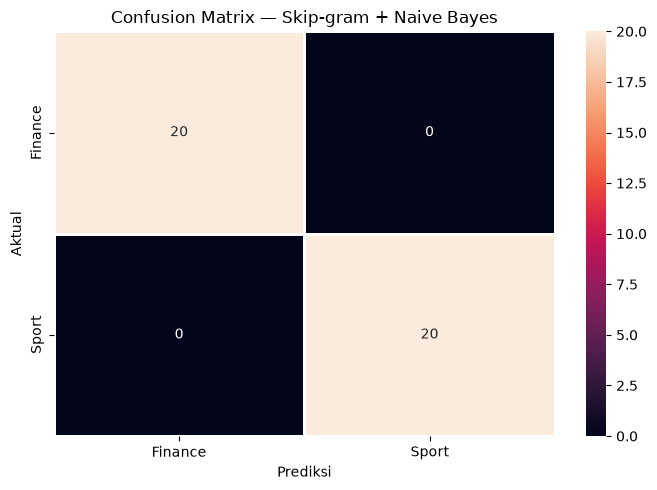

In [14]:
cm=confusion_matrix(y_test,y_pred,labels=["finance","sport"])
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Finance","Sport"],yticklabels=["Finance","Sport"],linewidths=1)
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title("Confusion Matrix — Skip-gram + Naive Bayes")
plt.tight_layout(); plt.show()

## 14. PCA 2D Vektor Dokumen

**Principal Component Analysis (PCA)** mereduksi dimensi vektor dokumen dari **100 dimensi menjadi 2 dimensi** untuk keperluan visualisasi. Tanpa reduksi dimensi, tidak mungkin memplot data di layar.

### Cara Kerja PCA

PCA mencari arah-arah (komponen utama) di mana data memiliki variasi terbesar. Transformasi linear PCA:

$$\mathbf{z} = \mathbf{W}^\top \mathbf{x}$$

Di mana:
- $\mathbf{x} \in \mathbb{R}^{100}$ = vektor dokumen asli (100 dimensi)
- $\mathbf{W} \in \mathbb{R}^{100 \times 2}$ = matriks proyeksi — berisi 2 *eigenvector* dengan *eigenvalue* terbesar dari matriks kovarians data
- $\mathbf{z} \in \mathbb{R}^2$ = koordinat 2D untuk di-plot sebagai scatter plot

**Matriks kovarians:**
$$\Sigma = \frac{1}{N} X^\top X \quad (\text{setelah mean-centering})$$

**Eigenvector** dari $\Sigma$ yang bersesuaian dengan dua **eigenvalue terbesar** dipilih sebagai sumbu PC1 dan PC2.

### Explained Variance Ratio

Ditampilkan di label sumbu grafik, menunjukkan persentase informasi yang dipertahankan:
```
PC1 (45.32%)  ← Komponen pertama menjelaskan 45% variasi data
PC2 (18.71%)  ← Komponen kedua menjelaskan 18% variasi data
Total: 64.03% informasi dipertahankan dalam visualisasi 2D
```

### Interpretasi Plot

- **Kluster terpisah** (sport dan finance tidak tumpang tindih): Word2Vec berhasil menangkap perbedaan semantik antara dua kategori
- **Tumpang tindih besar**: Fitur Word2Vec kurang mampu membedakan kedua kelas → perlu peningkatan model atau data

Seluruh data (train + test) digunakan untuk PCA agar visualisasi lebih representatif dari distribusi keseluruhan dataset.


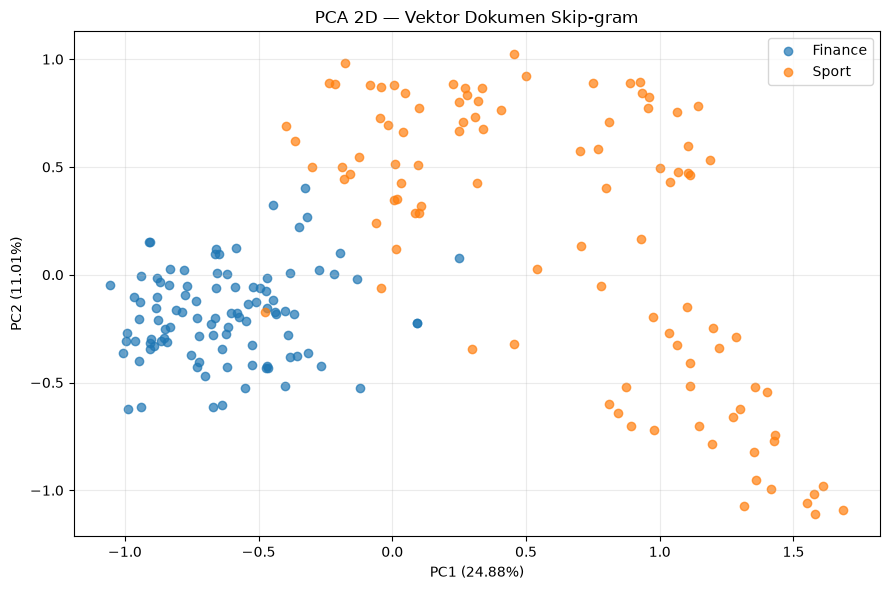

Total variance: 35.89%


In [15]:
X_all_eval=np.vstack([X_train,X_test]); y_all_eval=np.concatenate([y_train,y_test])
pca=PCA(n_components=2,random_state=RANDOM_STATE)
X_pca=pca.fit_transform(X_all_eval)
plt.figure(figsize=(9,6))
for kelas in ["finance","sport"]:
    mask=np.array(y_all_eval)==kelas
    plt.scatter(X_pca[mask,0],X_pca[mask,1],label=kelas.capitalize(),alpha=.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA 2D — Vektor Dokumen Skip-gram"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"Total variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

## 15. Probabilitas Prediksi

**Gaussian Naive Bayes** tidak hanya menghasilkan label prediksi, tetapi juga **probabilitas posterior** untuk setiap kelas. Ini berguna untuk mengukur tingkat keyakinan model terhadap setiap prediksi.

### Rumus Probabilitas Posterior

$$P(C \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid C) \cdot P(C)}{\sum_{c'} P(\mathbf{x} \mid c') \cdot P(c')}$$

Karena ada dua kelas, $P(\text{Finance}\mid\mathbf{x}) + P(\text{Sport}\mid\mathbf{x}) = 1$.

### Interpretasi Probabilitas

```
Contoh dokumen tentang "kinerja saham pertumbuhan ekonomi":
P(Finance) = 0.8723  → 87.23%  ← kelas prediksi
P(Sport)   = 0.1277  → 12.77%
Prediksi: FINANCE (keyakinan tinggi ✓)

Contoh dokumen ambigu "investasi klub sepakbola":
P(Finance) = 0.5134  → 51.34%  ← kelas prediksi
P(Sport)   = 0.4866  → 48.66%
Prediksi: FINANCE (keyakinan rendah — perlu peninjauan manual)
```

Probabilitas yang mendekati **0.5 untuk kedua kelas** menandakan dokumen yang **ambigu** — berada di perbatasan dua kategori. Informasi ini berguna untuk:
- Menentukan *confidence threshold* yang lebih konservatif (mis. hanya terima prediksi jika > 70%)
- Mengidentifikasi dokumen yang perlu ditinjau secara manual
- Mengukur kepercayaan model secara keseluruhan terhadap seluruh dataset uji


In [16]:
y_proba=nb_model.predict_proba(X_test)
df_proba=pd.DataFrame({"ID":df.loc[test_idx,"id"].values,"Label Aktual":y_test,"P(Finance)":y_proba[:,0],"P(Sport)":y_proba[:,1],"Prediksi":y_pred})
display(df_proba.style.format({"P(Finance)":"{:.4f}","P(Sport)":"{:.4f}"}))

,ID,Label Aktual,P(Finance),P(Sport),Prediksi
0,138,finance,1.0000,0.0000,finance
1,41,sport,0.0000,1.0000,sport
2,96,sport,0.0000,1.0000,sport
3,97,sport,0.0000,1.0000,sport
4,124,finance,1.0000,0.0000,finance
5,5,sport,0.0000,1.0000,sport
6,130,finance,1.0000,0.0000,finance
7,81,sport,0.0003,0.9997,sport
8,62,sport,0.0000,1.0000,sport
9,187,finance,1.0000,0.0000,finance


## 16. Model Final untuk Deployment

### Mengapa Dilatih Ulang pada Semua Data?

Setelah evaluasi selesai pada data test, model **dilatih ulang menggunakan seluruh data** (train + test) sebelum deployment. Logikanya:

```
Fase Evaluasi:
  80% data → train model_eval → evaluasi pada 20% test
                                         ↓
                          Performa sudah diketahui dan diterima
                                         ↓
Fase Deployment:
  100% data → train model_final → simpan ke model.pkl
```

**Alasannya**: Model yang melihat lebih banyak data umumnya lebih baik. Setelah kita puas dengan performa hasil evaluasi, ada gunanya memanfaatkan seluruh data yang tersedia untuk model produksi.

> **Penting:** Model final ini **tidak dievaluasi lagi** setelah dilatih pada semua data. Evaluasi sudah dilakukan sebelumnya pada data test yang terpisah. Ini adalah praktik standar dalam *machine learning deployment*.


In [17]:
corpus_all=df["tokens_model"].tolist()
model_final_w2v=Word2Vec(sentences=corpus_all,vector_size=VECTOR_SIZE,window=WINDOW_SIZE,min_count=MIN_COUNT,sg=1,workers=1,epochs=EPOCHS,seed=RANDOM_STATE)
X_all_final=np.vstack([document_vector(t,model_final_w2v,VECTOR_SIZE) for t in corpus_all])
y_all_final=df["label"].values
model_final_nb=GaussianNB().fit(X_all_final,y_all_final)
print("Model final siap. Vocabulary:",len(model_final_w2v.wv))

Model final siap. Vocabulary: 3070


## 17. Simpan `model.pkl`

Model disimpan menggunakan **pickle** dalam bentuk *dictionary* yang mengemas semua komponen yang dibutuhkan untuk prediksi:

```python
model_package = {
    "word2vec":    model_final_w2v,     # model Word2Vec (vocabulary + vektor)
    "naive_bayes": model_final_nb,      # Gaussian Naive Bayes (μ, σ² per kelas)
    "stopwords":   stopword_set,        # set stopword yang sama saat training
    "vector_size": VECTOR_SIZE,         # 100 → validasi konsistensi
    "window_size": WINDOW_SIZE,         # 4 → metadata konfigurasi
    "min_count":   MIN_COUNT,           # 2 → metadata
    "epochs":      EPOCHS,              # 40 → metadata
    "label_names": ["finance", "sport"],# nama kelas untuk interpretasi
    "version":     "UTS-PPW-Skipgram-NB"  # versioning
}
```

### Mengapa Semua Komponen Dikemas Bersama?

Agar preprocessing saat **prediksi konsisten dengan saat training**. Jika stopword berbeda, atau vector_size tidak sama, hasil prediksi bisa kacau. Dengan satu file `model.pkl`, aplikasi Streamlit hanya perlu membaca satu file tanpa khawatir inkonsistensi.

Ini mencegah **training-serving skew** — salah satu penyebab bug paling umum di sistem ML produksi.

File `model.pkl` diverifikasi ulang (`pickle.load`) segera setelah disimpan untuk memastikan tidak ada korupsi data.


In [18]:
model_package={"word2vec":model_final_w2v,"naive_bayes":model_final_nb,"stopwords":stopword_set,"vector_size":VECTOR_SIZE,"window_size":WINDOW_SIZE,"min_count":MIN_COUNT,"epochs":EPOCHS,"label_names":["finance","sport"],"version":"UTS-PPW-Skipgram-NB"}
with open("model.pkl","wb") as f: pickle.dump(model_package,f)
print("✓ model.pkl berhasil disimpan di folder proyek.")
with open("model.pkl","rb") as f: check=pickle.load(f)
print("Isi package:",check.keys())

✓ model.pkl berhasil disimpan di folder proyek.
Isi package: dict_keys(['word2vec', 'naive_bayes', 'stopwords', 'vector_size', 'window_size', 'min_count', 'epochs', 'label_names', 'version'])


# 18. Live Crawl + Prediksi URL
Bagian ini mengambil isi artikel dari URL secara langsung, melakukan preprocessing yang sama, mengubahnya menjadi document vector, lalu menggunakan model final untuk menentukan `sport` atau `finance`.

### Alur Pipeline End-to-End

```
URL Berita
    ↓
crawl_berita(url)
    ├─ Lapis 1: Trafilatura → teks bersih berkualitas tinggi
    └─ Lapis 2: BeautifulSoup → fallback jika Trafilatura gagal
    ↓
Teks Mentah (string panjang)
    ↓
preprocess_live(text, stopwords)
    ├─ Lowercase semua huruf
    ├─ Hapus karakter non-alfabet (angka, simbol, tanda baca)
    ├─ Normalisasi spasi ganda
    └─ Filter stopword + kata pendek (len ≤ 1)
    ↓
Tokens Bersih (list of str)
    ↓
document_vector(tokens, model_word2vec, 100)
    └─ Mean pooling vektor kata → satu vektor 100 dimensi
    ↓
nb_model.predict_proba(vector)
    ↓
Label: "sport" / "finance"  +  Probabilitas per kelas
```

### `crawl_berita()` — Strategi Dua Lapis

**Lapis 1 — Trafilatura** (utama, lebih akurat):
- Menggunakan algoritma berbasis ML untuk mengekstrak konten artikel utama
- Secara otomatis membuang navigasi, iklan, header, footer, sidebar
- Menghasilkan teks bersih berkualitas tinggi
- Fallback ke Lapis 2 jika gagal atau hasil < 100 karakter

**Lapis 2 — BeautifulSoup** (fallback, lebih manual):
- Fetch HTML menggunakan `requests` dengan header `User-Agent` untuk menghindari blokir
- Hapus elemen non-konten: `script, style, noscript, nav, footer`
- Ambil teks dari semua tag `<p>` (paragraf utama artikel)
- Lebih rentan terhadap noise tetapi lebih kompatibel

### `preprocess_live()` — Konsistensi Preprocessing

```python
def preprocess_live(text, stopwords):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())  # angka & simbol → spasi
    text = re.sub(r"\s+", " ", text).strip()                 # normalisasi spasi
    return [w for w in text.split() if w not in stopwords and len(w) > 1]
```

Langkah ini **harus identik** dengan preprocessing saat training. Perbedaan sekecil apapun (mis. urutan lowercase vs hapus simbol) bisa menghasilkan token berbeda → representasi vektor berbeda → prediksi tidak akurat.

> **Catatan:** Keberhasilan crawling bergantung pada struktur halaman dan kebijakan akses (robots.txt) situs sumber.


In [19]:
import requests
import trafilatura
from bs4 import BeautifulSoup
def crawl_berita(url):
    try:
        html=trafilatura.fetch_url(url)
        if html:
            text=trafilatura.extract(html,include_comments=False,include_tables=False)
            if text and len(text.strip())>100: return text.strip()
    except Exception as e:
        print("Trafilatura gagal:",e)
    response=requests.get(url,timeout=20,headers={"User-Agent":"Mozilla/5.0"})
    response.raise_for_status()
    soup=BeautifulSoup(response.text,"html.parser")
    for tag in soup(["script","style","noscript","nav","footer"]): tag.decompose()
    return " ".join(p.get_text(" ",strip=True) for p in soup.find_all("p") if p.get_text(strip=True))
def preprocess_live(text,stopwords):
    text=re.sub(r"[^a-zA-ZÀ-ÿ\s]"," ",str(text).lower())
    text=re.sub(r"\s+"," ",text).strip()
    return [w for w in text.split() if w not in stopwords and len(w)>1]
def prediksi_live(text,package):
    tokens=preprocess_live(text,package["stopwords"])
    vec=document_vector(tokens,package["word2vec"],package["vector_size"]).reshape(1,-1)
    pred=package["naive_bayes"].predict(vec)[0]
    probs=package["naive_bayes"].predict_proba(vec)[0]
    classes=package["naive_bayes"].classes_
    return pred,{str(c):float(p) for c,p in zip(classes,probs)},tokens

## 19. Contoh Input Link Berita

Notebook meminta URL berita secara interaktif melalui `input()`. Setelah URL dimasukkan:
1. `crawl_berita()` mengekstrak teks artikel
2. Ditampilkan cuplikan 1500 karakter pertama untuk verifikasi konten

**Contoh URL yang bisa digunakan:**

| Kategori | Contoh URL |
|---|---|
| Sport | `https://sport.detik.com/sepakbola/...` |
| Finance | `https://finance.detik.com/berita-ekonomi-bisnis/...` |
| Olahraga | `https://www.kompas.com/sports/...` |
| Bisnis | `https://www.cnbcindonesia.com/market/...` |

> **Catatan:** Beberapa situs memblokir scraping otomatis atau memerlukan autentikasi. Jika crawling gagal, coba URL dari sumber lain atau salin teks artikel secara manual.


In [20]:
# Masukkan URL berita saat notebook dijalankan
url_input=input("Masukkan URL berita: ").strip()
if not url_input: raise ValueError("URL tidak boleh kosong.")
print("Mengambil isi berita...")
isi_live=crawl_berita(url_input)
print("Jumlah karakter:",len(isi_live))
print("\nCuplikan isi:")
print(isi_live[:1500])

Masukkan URL berita:  https://finance.detik.com/energi/d-8696671/elnusa-perkuat-ketahanan-bbm-jelang-pertamina-grand-prix-of-indonesia


Mengambil isi berita...
Jumlah karakter: 5322

Cuplikan isi:
Menjelang gelaran Pertamina Grand Prix of Indonesia 2026 pada 9-11 Oktober 2026 di Pertamina Mandalika International Circuit, aktivitas masyarakat dan mobilitas pengunjung di Lombok diperkirakan meningkat. Untuk menjaga ketersediaan energi di tengah momentum tersebut, PT Elnusa Petrofin (EPN), anak usaha PT Elnusa Tbk (IDX: ELSA), memperkuat kesiapan distribusi BBM sekaligus meningkatkan aspek keselamatan dan kesiapan armada serta personel di seluruh Pulau Lombok.
Kesiapan distribusi telah dimulai sejak 4 Oktober 2026 dengan melakukan penyaluran BBM ke SPBU sebagai langkah pengamanan stok menjelang rangkaian event. EPN menyiagakan 28 unit Mobil Tangki (MT) dengan total kapasitas 440 KL dan 136 Awak Mobil Tangki (AMT), serta diperkuat dua unit MT spot charter dengan kapasitas 32 KL.
Distribusi mencakup BBM dari Integrated Terminal (IT) Ampenan menuju 72 SPBU dan 45 Pertashop di Pulau Lombok. Untuk memperkuat kesiapan di kawasa

In [21]:
with open("model.pkl","rb") as f: package=pickle.load(f)
prediksi,probabilitas,tokens_live=prediksi_live(isi_live,package)
print("\n"+"="*60)
print("HASIL KLASIFIKASI BERITA LIVE")
print("="*60)
print("Prediksi:",prediksi.upper())
print("Jumlah token:",len(tokens_live))
for kelas,nilai in probabilitas.items(): print(f"{kelas.capitalize():8s}: {nilai*100:.2f}%")
if prediksi=="sport": print("\n🏆 Berita ini diprediksi sebagai BERITA SPORT.")
elif prediksi=="finance": print("\n💰 Berita ini diprediksi sebagai BERITA FINANCE.")


HASIL KLASIFIKASI BERITA LIVE
Prediksi: FINANCE
Jumlah token: 523
Finance : 100.00%
Sport   : 0.00%

💰 Berita ini diprediksi sebagai BERITA FINANCE.


# Web deploy

Aplikasi untuk klasifikasi berita dapat anda gunakan di tautan berikut:
https://klasifikasi-berita-uts.streamlit.app/

# Kesimpulan
Word2Vec Skip-gram digunakan untuk mempelajari representasi vektor kata, kemudian Mean Pooling mengubah setiap berita menjadi satu vektor dokumen. Gaussian Naive Bayes melakukan klasifikasi dua kelas, yaitu `sport` dan `finance`. Evaluasi dilengkapi tabel prediksi data uji, confusion matrix, PCA, dan probabilitas.

Model final disimpan sebagai `model.pkl`. Notebook juga menyediakan contoh live crawling URL dan prediksi kategori berita. Keberhasilan crawling bergantung pada struktur halaman dan respons situs sumber.